# CARDIO GOOD FITNESS CUSTOMER SEGMENTATION AND PRODUCT ANALYSIS

Importing all the libraries needed for the project 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

I copied and pasted the dataset pathway that I am using for this EDA

In [2]:
df=pd.read_csv(r"C:\Users\PC\Documents\.ipynb_projects\CardioGoodFitness.csv")

## DATA VALIDATION AND QUALITY CHECKS

To start, i want to know the shape of my datasets

In [4]:
df.shape

(180, 9)

I want to see what the datasets columns look like

In [5]:
df.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

The following cell is to verify the types of data-type I have in my variables. 

In [6]:
df.dtypes

Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object

Renaming the columns to make each column clear to non-technical readers. 

In [7]:
df.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

In [8]:
df=df.rename(columns={'Product':'Treadmill_Model',
                   'Education':'Education_Level',
                   'MaritalStatus':'Marital_Status',
                   'Usage':'Weekly_Usage',
                   'Fitness':'Fitness_Level',
                   'Miles':'Weekly_Miles'})

In [9]:
df

,Treadmill_Model,Age,Gender,Education_Level,Marital_Status,Weekly_Usage,Fitness_Level,Income,Weekly_Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,TM798,40,Male,21,Single,6,5,83416,200
176,TM798,42,Male,18,Single,5,4,89641,200
177,TM798,45,Male,16,Single,5,5,90886,160
178,TM798,47,Male,18,Partnered,4,5,104581,120


Data looked clean, but in the next cell, I want to verify the quality of the data before exploration. 
Firstly, I will check if there are missing values.

In [10]:
df.isna().sum()

Treadmill_Model    0
Age                0
Gender             0
Education_Level    0
Marital_Status     0
Weekly_Usage       0
Fitness_Level      0
Income             0
Weekly_Miles       0
dtype: int64

The above returns that no missing values were detected, in that I do not remove any row.

Next cell, I will check for duplicates, and if there are duplicates, I will do deduplication because duplicate customers would bias product counts.

In [11]:
df.duplicated().sum()

np.int64(0)

In the cell below, I want to verify data types to ensure all data types are valid and to make sure that Pandas stores the Treadmill model, Gender and Marital Status columns more efficiently and treats it as category type and not like ordinary text.

In [12]:
df['Treadmill_Model'] = df['Treadmill_Model'].astype('category')
df['Gender'] = df['Gender'].astype('category')
df['Marital_Status'] = df['Marital_Status'].astype('category')

In [13]:
df.dtypes

Treadmill_Model    category
Age                   int64
Gender             category
Education_Level       int64
Marital_Status     category
Weekly_Usage          int64
Fitness_Level         int64
Income                int64
Weekly_Miles          int64
dtype: object

Next, I want to standardise categorical values by converting values into a single, consistent format to avoid issues like "male" VS "Male", making sure the same category is represented consistently. But before then, I want to review the dataset by using df.unique() value checks to see if there are extra spaces, casing issues, inconsistent labels... 

After reviewing, no inconsistencies such as casing or spacing variations were found, so no standardisation transformations were required.

In [14]:
df['Treadmill_Model'].unique()
df['Gender'].unique()
df['Marital_Status'].unique()

['Single', 'Partnered']
Categories (2, object): ['Partnered', 'Single']

Next cell, I want to validate ranges to remove any potential outliers, ensuring that the values make sense in the real world and that there are no out-of-range values.

Numeric columns were reviewed using descriptive statistics below to validate realistic value ranges. 
All variables (Age, Education Level, Weekly Usage, Fitness Level, Income, and Weekly Miles) fell within plausible real-world limits, and no invalid or extreme values were identified that required removal.

In [15]:
df.describe()

,Age,Education_Level,Weekly_Usage,Fitness_Level,Income,Weekly_Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


The dataset was reviewed to ensure data quality and suitability for analysis.

The dataset was assessed for missing values, duplicates, incorrect data types, inconsistent categories, and invalid ranges. 

### Checks Performed:
- Verified absence of missing values across all columns.
- Confirmed no duplicate customer records.
- Converted categorical variables (Product, Gender, MaritalStatus) to appropriate data types.
- Standardised categorical values to ensure consistent grouping.
- Validated numeric ranges for Age, Income, Fitness, and Usage to confirm real-world plausibility.
- Reviewed overall data consistency to ensure alignment with business context.

No critical data quality issues were identified that would impact the analysis.

In [16]:
df

,Treadmill_Model,Age,Gender,Education_Level,Marital_Status,Weekly_Usage,Fitness_Level,Income,Weekly_Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,TM798,40,Male,21,Single,6,5,83416,200
176,TM798,42,Male,18,Single,5,4,89641,200
177,TM798,45,Male,16,Single,5,5,90886,160
178,TM798,47,Male,18,Partnered,4,5,104581,120


After calling the df in above cell, a manual consistency review was conducted to assess the logical relationship between variables; usage frequency, fitness level, and miles covered. Variations in miles for similar usage frequencies were deemed realistic, as session duration and intensity differ between customers. 

No contradictions or unit inconsistencies were identified across customer attributes and usage metrics that required data correction.

## EDA IN FULL CONTEXT

Business Problem Statement

A fitness equipment company wants to understand how different customer segments purchase different treadmill models in order to improve product targeting and marketing strategy.

Analysis Question
•	Which customer segments buy each treadmill model?
•	Do income and fitness levels affect or influence product choice?
•	Are premium models bought by higher-income or more active customers?
•	Is usage frequency linked to model type?
•	Are certain products over- or under-targeted?
•	Which product should be marketed to which demographic?


### CUSTOMER BASELINE
The cell below is to understand the customer's baseline by knowing who the customers are and whether the dataset 
is balanced or skewed. 
This will answer
Are customers mostly young or older?
Is income evenly spread?
Are most users beginners or advanced?

In [17]:
df[['Age','Weekly_Usage','Fitness_Level','Income','Weekly_Miles']].describe()

,Age,Weekly_Usage,Fitness_Level,Income,Weekly_Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.084797,0.958869,16506.684226,51.863605
min,18.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,7.000000,5.000000,104581.000000,360.000000


### PRODUCT DISTRIBUTION
This run will show which treadmill models sell more and Whether any model dominates the dataset

In [18]:
df['Treadmill_Model'].value_counts()

Treadmill_Model
TM195    80
TM498    60
TM798    40
Name: count, dtype: int64

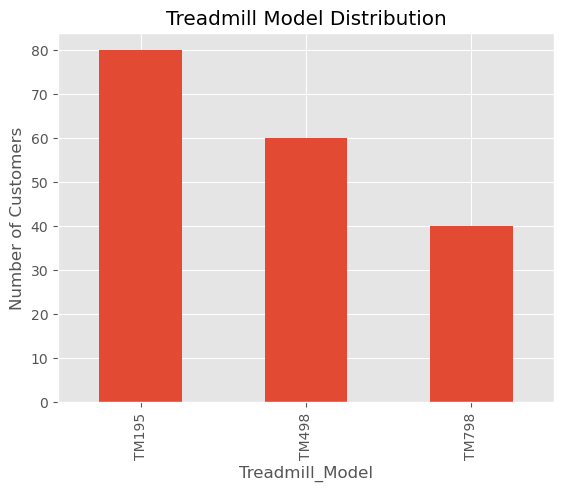

In [19]:
ax=df['Treadmill_Model'].value_counts().plot(kind='bar')
plt.title('Treadmill Model Distribution')
plt.ylabel('Number of Customers')
plt.show()

The next cell is to see if there are differences between models and customers. 

Which CUSTOMER SEGMENTS BUY each treadmill model
1. Income by Threadmill Model
2. Fitness Level by Threadmill Model
3. Weekly Usage by Threadmill Model

In [20]:
df.groupby('Treadmill_Model',observed=True)['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Treadmill_Model,,,,,,,,
TM195,80.0,46418.025,9075.783190,29562.0,38658.00,46617.0,53439.0,68220.0
TM498,60.0,48973.650,8653.989388,31836.0,44911.50,49459.5,53439.0,67083.0
TM798,40.0,75441.575,18505.836720,48556.0,58204.75,76568.5,90886.0,104581.0


In [21]:
df.groupby('Treadmill_Model',observed=True)['Fitness_Level'].mean()

Treadmill_Model
TM195    2.9625
TM498    2.9000
TM798    4.6250
Name: Fitness_Level, dtype: float64

In [22]:
df.groupby('Treadmill_Model',observed=True)['Weekly_Usage'].mean()

Treadmill_Model
TM195    3.087500
TM498    3.066667
TM798    4.775000
Name: Weekly_Usage, dtype: float64

### PREMIUM VS NON-PREMIUM BEHAVIOUR
This is to check if premium models are bought by higher-income or more active customers?

In [23]:
df.groupby('Treadmill_Model',observed=True)[['Income','Weekly_Usage','Fitness_Level','Weekly_Miles']].mean()

,Income,Weekly_Usage,Fitness_Level,Weekly_Miles
Treadmill_Model,,,,
TM195,46418.025,3.087500,2.9625,82.787500
TM498,48973.650,3.066667,2.9000,87.933333
TM798,75441.575,4.775000,4.6250,166.900000


### USAGE BEHAVIOUR vs PRODUCT
This will indicate if the usage frequency is linked to the model type

In [24]:
df.groupby('Treadmill_Model',observed=True)['Weekly_Usage'].value_counts().unstack()

Weekly_Usage,2,3,4,5,6,7
Treadmill_Model,,,,,,
TM195,19.0,37.0,22.0,2.0,NaN,NaN
TM498,14.0,31.0,12.0,3.0,NaN,NaN
TM798,NaN,1.0,18.0,12.0,7.0,2.0


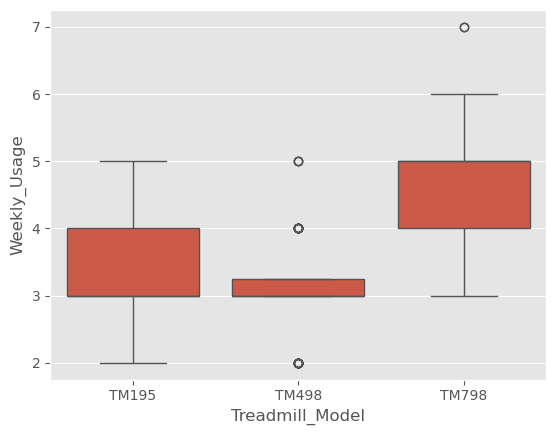

In [25]:
sns.boxplot(x='Treadmill_Model',y='Weekly_Usage',data=df)
plt.show()

## ANALYSIS
**Question 1** 
**Which customer segments buy each model?**

In this question, I am answering What type of customers (demographically and financially) tend to buy each treadmill model?

In [26]:
df['Treadmill_Model'].value_counts()

Treadmill_Model
TM195    80
TM498    60
TM798    40
Name: count, dtype: int64

Gneder and Marital Status by Model

In [27]:
df.groupby('Treadmill_Model',observed=True)['Gender'].value_counts(normalize=True)

Treadmill_Model  Gender
TM195            Female    0.500000
                 Male      0.500000
TM498            Male      0.516667
                 Female    0.483333
TM798            Male      0.825000
                 Female    0.175000
Name: proportion, dtype: float64

In [28]:
df.groupby('Treadmill_Model',observed=True)['Marital_Status'].value_counts(normalize=True)

Treadmill_Model  Marital_Status
TM195            Partnered         0.600
                 Single            0.400
TM498            Partnered         0.600
                 Single            0.400
TM798            Partnered         0.575
                 Single            0.425
Name: proportion, dtype: float64

Age, Income and Fitness Profilling
I am Identifying budget buyers, premium buyers and entry vs advanced users.

In [29]:
df.groupby('Treadmill_Model', observed=True)[
    ['Age', 'Income', 'Fitness_Level']
].describe()


Age                                                  Income  \
                count   mean       std   min    25%   50%    75%   max  count   
Treadmill_Model                                                                 
TM195            80.0  28.55  7.221452  18.0  23.00  26.0  33.00  50.0   80.0   
TM498            60.0  28.90  6.645248  19.0  24.00  26.0  33.25  48.0   60.0   
TM798            40.0  29.10  6.971738  22.0  24.75  27.0  30.25  48.0   40.0   

                            ...                    Fitness_Level          \
                      mean  ...      75%       max         count    mean   
Treadmill_Model             ...                                            
TM195            46418.025  ...  53439.0   68220.0          80.0  2.9625   
TM498            48973.650  ...  53439.0   67083.0          60.0  2.9000   
TM798            75441.575  ...  90886.0  104581.0          40.0  4.6250   

                                                    
                      std  min  25%  50%  75%  max  
Treadmill_Model                                     
TM195            0.664540  1.0  3.0  3.0  3.0  5.0  
TM498            0.629770  1.0  3.0  3.0  3.0  4.0  
TM798            0.667467  3.0  4.0  5.0  5.0  5.0  

[3 rows x 24 columns]

Usage behaviour as supporting evidence
This is to validate whether premium buyers actually use the treadmill more and to know if entry buyers are lighter user

In [30]:
df.groupby('Treadmill_Model', observed=True)[
    ['Weekly_Usage','Weekly_Miles']
].describe()

Weekly_Usage                                                \
                       count      mean       std  min  25%  50%   75%  max   
Treadmill_Model                                                              
TM195                   80.0  3.087500  0.782624  2.0  3.0  3.0  4.00  5.0   
TM498                   60.0  3.066667  0.799717  2.0  3.0  3.0  3.25  5.0   
TM798                   40.0  4.775000  0.946993  3.0  4.0  5.0  5.00  7.0   

                Weekly_Miles                                             \
                       count        mean        std   min    25%    50%   
Treadmill_Model                                                           
TM195                   80.0   82.787500  28.874102  38.0   66.0   85.0   
TM498                   60.0   87.933333  33.263135  21.0   64.0   85.0   
TM798                   40.0  166.900000  60.066544  80.0  120.0  160.0   

                               
                   75%    max  
Treadmill_Model                
TM195             94.0  188.0  
TM498            106.0  212.0  
TM798            200.0  360.0

To identify customer segments by treadmill model, I analysed demographic and behavioural characteristics including age, income, 
fitness level, gender, and marital status. Clear differences emerged across models, indicating distinct customer profiles. 
Entry-level models were primarily purchased by lower-income and lower-fitness customers, while premium models attracted 
higher-income, more fitness-oriented users with higher weekly usage.

**Question 2**
**Do income and fitness levels influence product choice?**

This is to understand if customers with higher income and higher fitness levels are more likely to buy certain treadmill models (especially premium ones). This will help the business price products correctly, target the right customers and avoid marketing premium products to the wrong audience.

Income vs Product Choice (Threadmill_Model)

In [31]:
df.groupby('Treadmill_Model',observed=True)['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Treadmill_Model,,,,,,,,
TM195,80.0,46418.025,9075.783190,29562.0,38658.00,46617.0,53439.0,68220.0
TM498,60.0,48973.650,8653.989388,31836.0,44911.50,49459.5,53439.0,67083.0
TM798,40.0,75441.575,18505.836720,48556.0,58204.75,76568.5,90886.0,104581.0


From the above cell, customers purchasing higher-end treadmill models tend to have significantly higher median and average income levels. Entry-level models are predominantly bought by lower-income customers, while premium models attract buyers with greater purchasing power, suggesting income plays a strong role in product selection.

Fitness Level vs Product Choice (Threadmill_Model)

In [32]:
df.groupby('Treadmill_Model',observed=True)['Fitness_Level'].describe()

,count,mean,std,min,25%,50%,75%,max
Treadmill_Model,,,,,,,,
TM195,80.0,2.9625,0.664540,1.0,3.0,3.0,3.0,5.0
TM498,60.0,2.9000,0.629770,1.0,3.0,3.0,3.0,4.0
TM798,40.0,4.6250,0.667467,3.0,4.0,5.0,5.0,5.0


By comparing the fitness level to the threadmill model above, Fitness level increases noticeably across treadmill models, with premium models being purchased primarily by customers who self-identify as highly fit. This suggests that more active users seek advanced treadmill features that align with their training intensity.

Below cell combine Income & Fitness

In [33]:
df.groupby('Treadmill_Model', observed=True)[
    ['Income', 'Fitness_Level']
].mean()

,Income,Fitness_Level
Treadmill_Model,,
TM195,46418.025,2.9625
TM498,48973.650,2.9000
TM798,75441.575,4.6250


There is a clear alignment between income and fitness levels across treadmill models. Customers with higher income and stronger fitness profiles consistently purchase premium models, while lower-income and less active customers gravitate toward entry-level products. This indicates that both economic capacity and fitness intensity significantly influence product choice.

Although treadmill tiers are not explicitly defined in the dataset, customer behaviour suggests clear differentiation for TM798, which attracts significantly higher-income and more fitness-oriented users. In contrast, TM195 and TM498 display overlapping customer profiles across income, fitness, and usage metrics, indicating potential product overlap rather than a distinct mid-tier positioning.

Visual confirmation

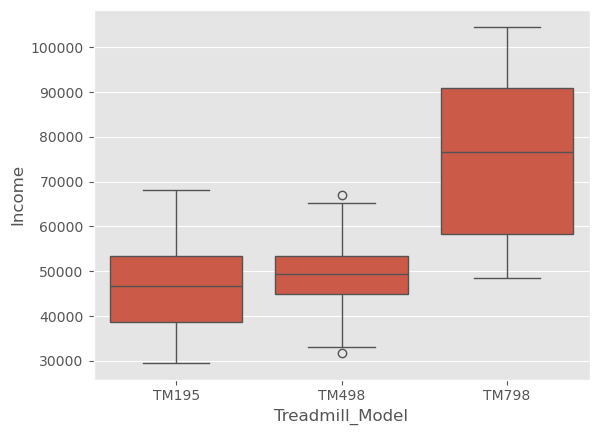

In [34]:
sns.boxplot(x='Treadmill_Model',y='Income',data=df)
plt.show()

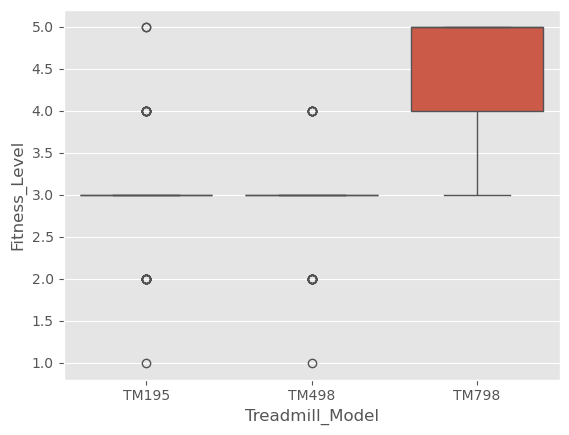

In [35]:
sns.boxplot(x='Treadmill_Model',y='Fitness_Level',data=df)
plt.show()

Income and fitness levels significantly influence treadmill model selection. Higher-income, highly fit customers disproportionately purchase premium models, while lower-income and less active users prefer entry-level options. This confirms that current product segmentation aligns well with customer capability and usage intensity.

**Question 3**

**Are premium models bought by higher-income or more active customers?**

In order to test whether premium models are bought by higher-income or more active customers, this analysis will focus on mean/median income by threadmill model, also activity and engagement of the customers. i.e weekly usage, fitness level, weekly miles.
Since the dataset does not label products as premium, Premium is defined based on observed customer behaviour.
From previous analysis TM798 consistently shows:
Highest average income
Highest fitness levels
Highest weekly usage
Highest weekly miles
Therefore, TM798 is treated as the premium model for this analysis.

From the previoulsy run code "PREMIUM VS NON-PREMIUM BEHAVIOUR" exploration at the EDA Section
I observed that TM798 has the
Highest income
Highest fitness level
Highest usage frequency
Highest miles covered

While TM195 & TM498 has
Similar income levels
Similar fitness and usage patterns
No clear activity advantage for TM498 over TM195

The above shows a clear pattern and clarifies that the premium treadmill model (TM798) is predominantly purchased by higher-income and more active customers. Buyers of TM798 demonstrate significantly higher average income, fitness levels, usage frequency, and weekly miles compared to customers purchasing other models.

In contrast, TM195 and TM498 attract customers with similar income and activity profiles, suggesting that premium purchasing behaviour is clearly differentiated only at the highest model level.

**BUSINESS INSIGHT**

Premium Model Purchasing Behaviour

Using customer income and activity metrics as behavioural proxies for product positioning, TM798 emerges as the premium treadmill model. Analysis shows that TM798 buyers have substantially higher average income, fitness levels, weekly usage, and miles run compared to buyers of other models. This indicates that premium products are primarily purchased by more affluent and fitness-oriented customers.

However, TM195 and TM498 display overlapping customer profiles, suggesting that premium purchasing behaviour is concentrated at the top-end model rather than across a gradual product ladder.

**Analysis Question 4**
**Is usage frequency linked to model type?**

This is to know if customers who buy different treadmill models use them at different frequencies. In other words; do premium or higher-end models attract heavier users?

To answer this, I will be using the metrics below:
Weekly_Usage - how often customers plan to use the treadmill
Treadmill_Model - the product category

In [36]:
df.groupby('Treadmill_Model',observed=True)['Weekly_Usage'].describe()

,count,mean,std,min,25%,50%,75%,max
Treadmill_Model,,,,,,,,
TM195,80.0,3.087500,0.782624,2.0,3.0,3.0,4.00,5.0
TM498,60.0,3.066667,0.799717,2.0,3.0,3.0,3.25,5.0
TM798,40.0,4.775000,0.946993,3.0,4.0,5.0,5.00,7.0


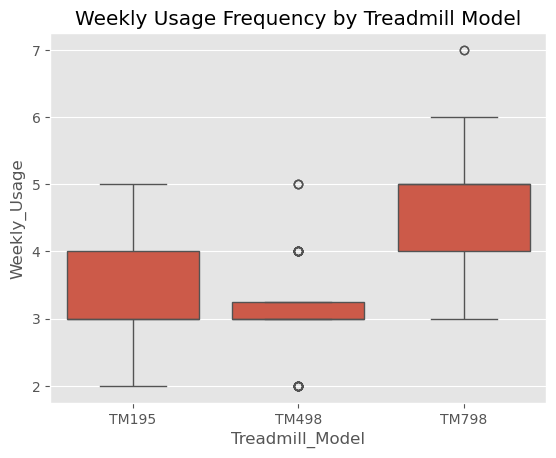

In [37]:
sns.boxplot(x='Treadmill_Model',y='Weekly_Usage',data=df)
plt.title('Weekly Usage Frequency by Treadmill Model')
plt.show()

**Observed Pattern**

From the descriptive statistics and boxplot:
TM798 shows
Highest median weekly usage
Higher upper quartile (75%)
More high-usage customers

While TM195 and TM498
Similar median usage
Overlapping distributions
No strong separation between the two

**BUSINESS INSIGHT**

Yes, usage frequency is clearly linked to treadmill model type, but primarily at the premium level.
Customers who purchase TM798 use their treadmills significantly more frequently compared to customers purchasing TM195 and TM498. This suggests that TM798 appeals to highly engaged and fitness-focused users.

In contrast, TM195 and TM498 show similar usage patterns, indicating that these models cater to moderate or casual users rather than distinct usage segments.

**Business Implication**

TM798 should be positioned and marketed as a high-performance treadmill for frequent users, while TM195 and TM498 can be targeted toward entry-level and moderate users where price and accessibility may be more influential than usage intensity.

**Question 5**
**Are certain products over- or under-targeted?**

Based on income, fitness level, and usage patterns from earlier questions and exploration

- TM798 is clearly and appropriately targeted, because it attracts high-income, highly active, fitness-oriented users and the Customer profile is distinct and consistent
  
- TM195 and TM498 show potential over-targeting or weak differentiation; their buyers have:
  - Similar income
  - Similar fitness levels
  - Similar usage frequency
TM498 does not show a strong behavioural step-up from TM195

In conclusion, there is no evidence of under-targeting in the dataset.
Instead, the data suggests overlap and possible mis-positioning between TM195 and TM498, while TM798 is well-positioned as a premium model.

The overlap between TM195 and TM498 customer profiles suggests potential repositioning opportunities. However, evaluating cross-selling strategies would require additional behavioural or marketing data beyond the scope of this dataset.

**Question 6**
**Which product should be marketed to which demographic?**

Data-Driven Product–Demographic Mapping

Based on all the metrics analysed (income, fitness level, usage, miles, age distribution indirectly), here is the most defensible mapping.

TM195 - Entry-Level / Casual Users
Target demographic:
- Lower–mid income customers
- Fitness level ≈ 2–3
- Weekly usage ≈ 2–3 times
- Likely beginners or casual exercisers

Marketing focus:
- Affordability
- Ease of use
- "Getting started with fitness"
- Convenience & basic health benefits

### Business takeaway
TM195 should be positioned as a starter treadmill, not pushed toward high-performance users.

TM498 - Mid-Tier / General Fitness Users
Target demographic:
- Mid-income customers
- Moderate fitness levels
- Regular but not intensive usage
- Users upgrading slightly from entry-level

Marketing focus:
- Balance between price and performance
- Durability
- “Step up your routine”
- Value for money

### Business takeaway
TM498 currently does not strongly differentiate itself from TM195 in customer behaviour.
Marketing must clearly justify why TM498 is a step up, otherwise customers will default to TM195.

TM798 - Premium / Fitness-Oriented Users
Target demographic:
- High-income customers
- High fitness levels (4–5)
- Frequent usage (≈ 5–7 times/week)
- High weekly mileage
- Fitness as a lifestyle, not a hobby

Marketing focus:
- Performance
- Advanced features
- Endurance
- Serious training & long-term investment

### Business takeaway
TM798 is correctly positioned as a premium product and should be marketed explicitly to affluent, highly active users.

### Executive Summary and Recommendations

Business Objective
This analysis aimed to understand how different customer segments purchase treadmill models in order to improve product targeting and marketing strategy

Key Insights Summary
- TM798 is purchased by significantly higher-income, highly active, fitness-oriented customers
- TM195 and TM498 attract overlapping customer segments with similar income and activity levels
- Usage frequency and weekly miles increase clearly with model tier
- Product differentiation is strongest at the premium level

Business Implications
What should the company do differently?
- Marketing efforts for TM798 should focus on performance, lifestyle, and long-term fitness commitment
- Entry and mid-tier models should emphasise accessibility, affordability, and habit-building
- Overlapping profiles between TM195 and TM498 suggest possible repositioning or clearer feature differentiation

Limitations and Next Steps
- The dataset does not include marketing channels, purchase timing, or customer lifetime data
- Future analysis could incorporate behavioural or transactional data to assess cross-selling opportunities

## Export Cleaned Dataset

In [41]:
df.to_csv("Cardio_Good_Fitness_Clean.csv", index=False)